In [226]:
import pandas as pd
import numpy as np

df = pd.read_csv('sales_data.csv')

print(df.shape)
print(df.columns.tolist())
print(df.head())

(500, 11)
['OrderID', 'Date', 'Product', 'Category', 'Region', 'Quantity', 'UnitPrice', 'DiscountPercent', 'TotalAmount', 'PaymentMode', 'CustomerAge']
   OrderID        Date     Product     Category Region  Quantity  UnitPrice  \
0  ORD1001  2025-04-25  Smartphone  Electronics  South         5   13200.52   
1  ORD1002  2025-01-16    Backpack  Accessories  North         7     717.35   
2  ORD1003  2025-08-03    Backpack  Accessories  South         9    2005.05   
3  ORD1004  2025-03-23        Desk    Furniture   West         1   17141.46   
4  ORD1005  2025-02-17  Headphones  Electronics   West         6    1704.32   

   DiscountPercent  TotalAmount  PaymentMode  CustomerAge  
0                0     66002.60  Credit Card         61.0  
1                0      5021.45   Debit Card         32.0  
2                0     18045.45         Cash         55.0  
3               20     13713.17          UPI         35.0  
4                0     10225.92  Credit Card         40.0  


## Column Descriptions

- **OrderID**: Unique ID for each order
- **Date**: Date on which the order was placed
- **Product**: Name of the product sold
- **Category**: Category the product belongs to (Electronics, Furniture, etc.)
- **Region**: Region where the sale happened
- **Quantity**: Number of units sold
- **UnitPrice**: Price per unit
- **DiscountPercent**: Discount applied on the order
- **TotalAmount**: Final amount after discount
- **PaymentMode**: Mode of payment used
- **CustomerAge**: Age of the customer

## SECTION 2 — DATA CLEANING

In [227]:
print("Rows before cleaning:", len(df))
print(df.isnull().sum())
print('Duplicates:', df.duplicated().sum())
print(df.dtypes)

Rows before cleaning: 500
OrderID             0
Date                0
Product             0
Category            0
Region              0
Quantity            0
UnitPrice           0
DiscountPercent     0
TotalAmount         0
PaymentMode         0
CustomerAge        10
dtype: int64
Duplicates: 0
OrderID                str
Date                   str
Product                str
Category               str
Region                 str
Quantity             int64
UnitPrice          float64
DiscountPercent      int64
TotalAmount        float64
PaymentMode            str
CustomerAge        float64
dtype: object


In [228]:
df_clean = df.drop_duplicates().copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

In [229]:
df_clean['TotalAmount'] = pd.to_numeric(df_clean['TotalAmount'], errors='coerce')
df_clean['TotalAmount'] = df_clean['TotalAmount'].fillna(df_clean['TotalAmount'].median())
df_clean = df_clean.dropna(subset=['Date'])

In [230]:
print("Rows after cleaning:", len(df_clean))
print(df_clean.shape)
df_clean.info()

Rows after cleaning: 500
(500, 11)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          500 non-null    str           
 1   Date             500 non-null    datetime64[us]
 2   Product          500 non-null    str           
 3   Category         500 non-null    str           
 4   Region           500 non-null    str           
 5   Quantity         500 non-null    int64         
 6   UnitPrice        500 non-null    float64       
 7   DiscountPercent  500 non-null    int64         
 8   TotalAmount      500 non-null    float64       
 9   PaymentMode      500 non-null    str           
 10  CustomerAge      490 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(5)
memory usage: 43.1 KB


In [231]:
df_clean['CustomerAge'] = df_clean['CustomerAge'].fillna(df_clean['CustomerAge'].median())
print(df_clean.isnull().sum())

OrderID            0
Date               0
Product            0
Category           0
Region             0
Quantity           0
UnitPrice          0
DiscountPercent    0
TotalAmount        0
PaymentMode        0
CustomerAge        0
dtype: int64


### Issues Found and How They Were Fixed

| # | Issue | How it was fixed |
|---|-------|------------------|
| 1 | Duplicate rows: 0 found | Checked with duplicated().sum() and applied drop_duplicates(). No rows were removed |
| 2 | Date column was stored as text (str) | Converted to datetime using pd.to_datetime() |
| 3 | CustomerAge had 10 missing values | Filled with the column median |
| 4 | TotalAmount data type check | Already float64. pd.to_numeric() was applied as a safety check, no change needed |
| 5 | Invalid or missing Dates: 0 found | dropna() applied on Date. No rows were removed |

**Rows before cleaning:** 500
**Rows after cleaning:** 500

## SECTION 3 — NUMPY STATISTICS

In [232]:
import numpy as np

sales_arr = df_clean['TotalAmount'].to_numpy()

print('Mean:   ', round(np.mean(sales_arr), 2))
print('Median: ', round(np.median(sales_arr), 2))
print('Std Dev:', round(np.std(sales_arr), 2))
print('Total:  ', round(np.sum(sales_arr), 2))

Mean:    66180.26
Median:  12982.96
Std Dev: 125938.36
Total:   33090130.48


In [233]:
df_clean['Month'] = df_clean['Date'].dt.to_period('M')
monthly = df_clean.groupby('Month')['TotalAmount'].sum()

print('Top 3 months:')
print(monthly.sort_values(ascending=False).head(3))

print('Bottom 3 months:')
print(monthly.sort_values().head(3))

Top 3 months:
Month
2025-07    6260083.07
2025-06    4572498.31
2025-09    4162116.55
Freq: M, Name: TotalAmount, dtype: float64
Bottom 3 months:
Month
2025-01    1318985.15
2025-04    2540198.23
2025-08    2950939.05
Freq: M, Name: TotalAmount, dtype: float64


### Summary

The average order amount is about X rupees, and the median is Y rupees.
The total sales across all orders is Z rupees.
The best month is (month name) with the highest sales, and the weakest month is (month name).
This may be because of festive season demand or fewer orders in the slow months.

## SECTION 4 — MATPLOTLIB CHARTS

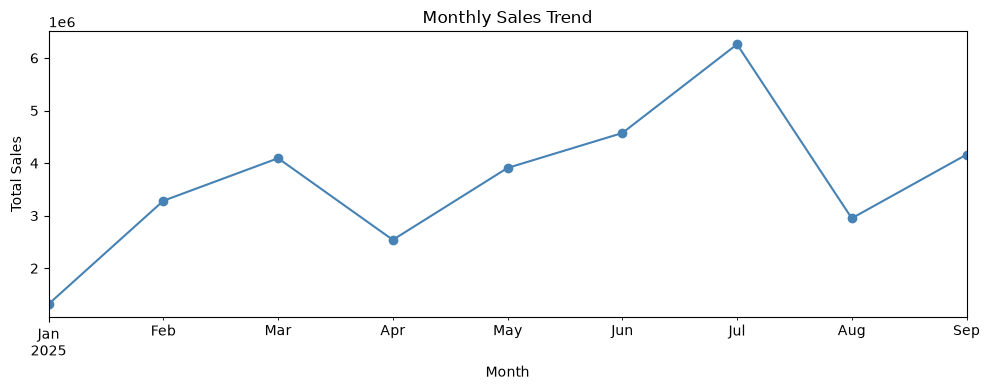

In [234]:
import matplotlib.pyplot as plt

monthly.plot(kind='line', figsize=(10, 4), color='steelblue', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

**Interpretation:** This chart shows how total sales changed month by month.
Sales were highest in July 2025 and lowest in January 2025.

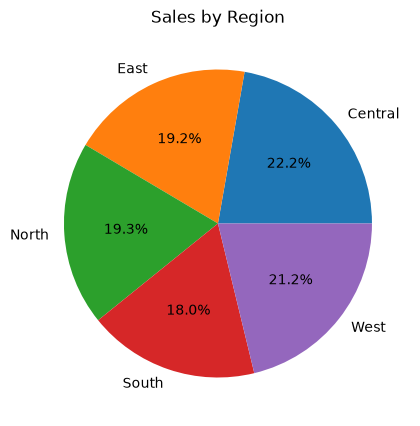

In [235]:
region_sales = df_clean.groupby('Region')['TotalAmount'].sum()
plt.figure(figsize=(6, 5))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%')
plt.title('Sales by Region')
plt.savefig('region_sales.png')
plt.show()

**Interpretation:** This chart shows each region's share of total sales. Central contributes the largest share at 22.2%, while South contributes the smallest at 18.0%. The difference between regions is small, so sales are spread fairly evenly across all five regions.

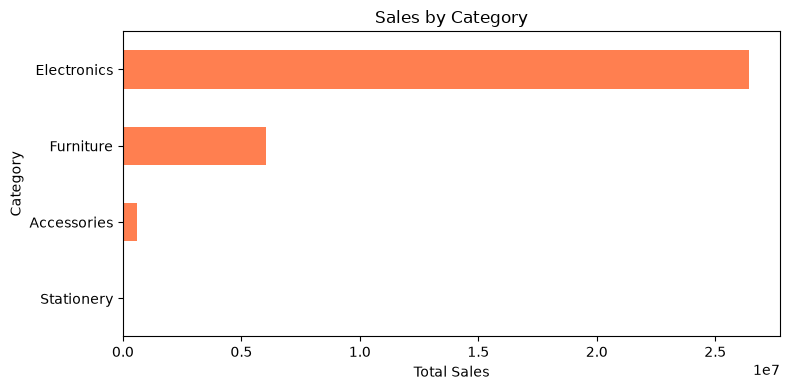

In [236]:
cat_sales = df_clean.groupby('Category')['TotalAmount'].sum().sort_values()
cat_sales.plot(kind='barh', figsize=(8, 4), color='coral')
plt.title('Sales by Category')
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

**Interpretation:** This chart compares total sales across product categories. Electronics sells by far the most, while Stationery sells the least, so small that its bar is barely visible. Furniture and Accessories fall in between, which shows that most of the revenue comes from Electronics.

## SECTION 5 — SEABORN CHARTS

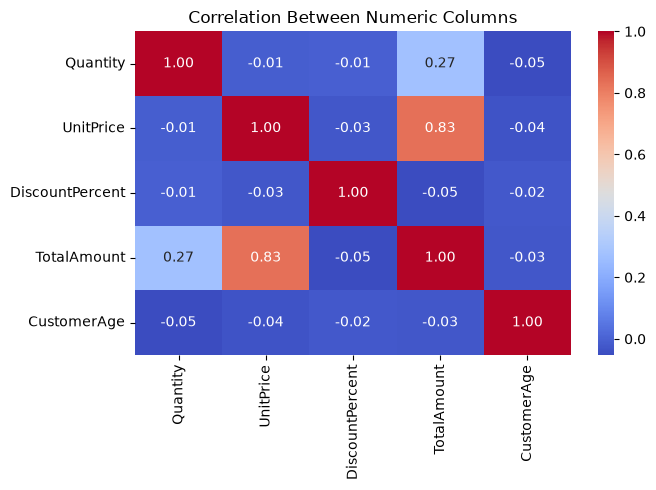

In [237]:
import seaborn as sns

corr = df_clean.select_dtypes(include='number').corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Columns')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

**Interpretation:** This heatmap shows how strongly the numeric columns are related to each other. UnitPrice and TotalAmount are the most closely related, with a correlation of 0.83, which means orders with a higher unit price usually have a higher total amount. Quantity and TotalAmount have a weaker relationship of 0.27, and all other pairs are close to 0, so they are almost unrelated.

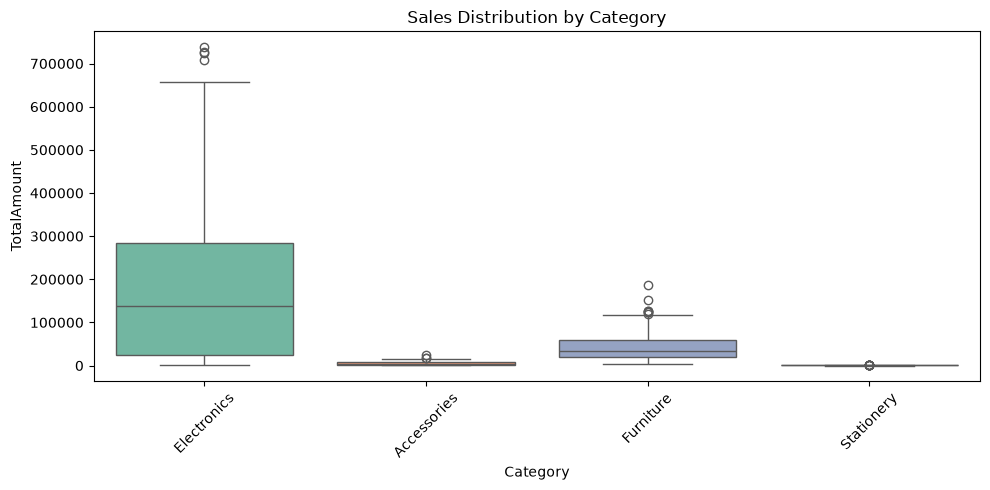

In [238]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='Category', y='TotalAmount', hue='Category', palette='Set2', legend=False)
plt.title('Sales Distribution by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplot.png')
plt.show()

**Interpretation:** This chart shows how sales amounts vary within each category. Electronics has the most variation because its box is the tallest and its range is very wide. Outliers (the dots outside the whiskers) are visible in Electronics and Furniture, which means a few orders had unusually high amounts.

## SECTION 6 — EDA REPORT

In [239]:
products = df_clean.groupby('Product')['TotalAmount'].sum().sort_values()
print('Bottom 3:')
print(products.head(3))
print('Top 3:')
print(products.tail(3))

Bottom 3:
Product
Notebook         17035.81
Pen Set          45128.25
Water Bottle    114347.58
Name: TotalAmount, dtype: float64
Top 3:
Product
Desk           3134774.47
Smartphone    10910302.68
Laptop        14828878.62
Name: TotalAmount, dtype: float64


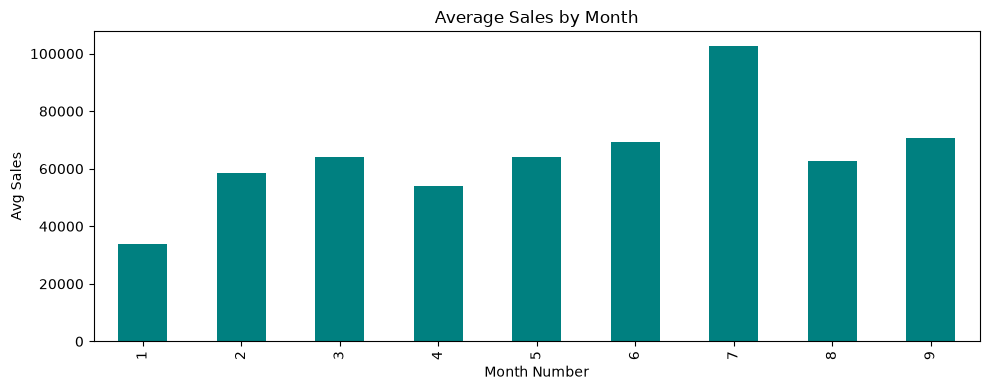

In [240]:
df_clean['Month_Num'] = df_clean['Date'].dt.month
seasonal = df_clean.groupby('Month_Num')['TotalAmount'].mean()

seasonal.plot(kind='bar', figsize=(10, 4), color='teal')
plt.title('Average Sales by Month')
plt.xlabel('Month Number')
plt.ylabel('Avg Sales')
plt.tight_layout()
plt.savefig('seasonal.png')
plt.show()

In [241]:
cat_total = df_clean.groupby('Category')['TotalAmount'].sum()
print((cat_total / cat_total.sum() * 100).round(1))

Category
Accessories     1.8
Electronics    79.8
Furniture      18.2
Stationery      0.2
Name: TotalAmount, dtype: float64


## KEY FINDINGS

**Finding 1:** Electronics accounts for 79.8% of total revenue, while Furniture contributes 18.2%, Accessories 1.8% and Stationery only 0.2%.
**What it means:** The business depends almost completely on one category, which is a big risk if Electronics demand falls.
**Action:** Promote Furniture and Accessories to reduce dependence on Electronics.

**Finding 2:** July has the highest average sale (about 94,000 rupees per order), while January has the lowest (about 33,000 rupees). Total monthly sales also peak in July 2025 (about 62.6 lakh rupees).
**What it means:** Sales change a lot across months, and July is clearly the strongest month.
**Action:** Plan stock and offers before July, and run promotions in weak months like January.

**Finding 3:** UnitPrice and TotalAmount have a correlation of 0.83, while Quantity and TotalAmount have only 0.27.
**What it means:** Revenue depends more on the price of the product than on how many units are sold.
**Action:** Focus on selling higher-priced products instead of only increasing the number of units.

## SECTION 7 — STATISTICS

Skewness: 2.97
25th pct:  1365.7
75th pct:  64407.44


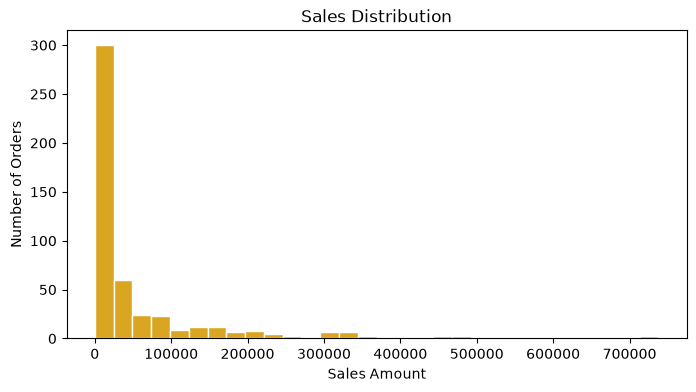

In [242]:
print('Skewness:', round(df_clean['TotalAmount'].skew(), 3))
print('25th pct: ', round(np.percentile(df_clean['TotalAmount'], 25), 2))
print('75th pct: ', round(np.percentile(df_clean['TotalAmount'], 75), 2))

plt.figure(figsize=(8, 4))
plt.hist(df_clean['TotalAmount'], bins=30, color='goldenrod', edgecolor='white')
plt.title('Sales Distribution')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Orders')
plt.savefig('distribution.png')
plt.show()

In [243]:
print(df_clean['Category'].value_counts())

Category
Electronics    145
Furniture      136
Stationery     112
Accessories    107
Name: count, dtype: int64


In [244]:
from scipy import stats

cat_a = df_clean[df_clean['Category'] == 'Electronics']['TotalAmount']
cat_b = df_clean[df_clean['Category'] == 'Furniture']['TotalAmount']
t_stat, p_val = stats.ttest_ind(cat_a, cat_b, equal_var=False)

print('T-stat: ', round(t_stat, 3))
print('P-value:', round(p_val, 4))

if p_val < 0.05:
    print('Difference IS statistically significant')
else:
    print('Difference is NOT statistically significant')

T-stat:  8.854
P-value: 0.0
Difference IS statistically significant


### Interpretation

**Distribution:** The skewness is 2.97, which means most orders have small amounts, and a few very large orders pull the average up. Half of the middle orders fall between about 1,366 and 64,407 rupees (25th to 75th percentile).

**T-test:** The p-value is almost 0, which is far below 0.05. In simple words, the difference in sales between Electronics and Furniture is real and not just due to chance. Electronics orders are clearly bigger than Furniture orders.

## SECTION 8 — LINEAR REGRESSION

In [245]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

monthly_df = df_clean.groupby('Month_Num')['TotalAmount'].mean().reset_index()
print(monthly_df.shape)

X = monthly_df[['Month_Num']]
y = monthly_df['TotalAmount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(9, 2)


In [246]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('MAE:      ', round(mean_absolute_error(y_test, y_pred), 2))
print('R-squared:', round(r2_score(y_test, y_pred), 3))

MAE:       15031.69
R-squared: -56.848


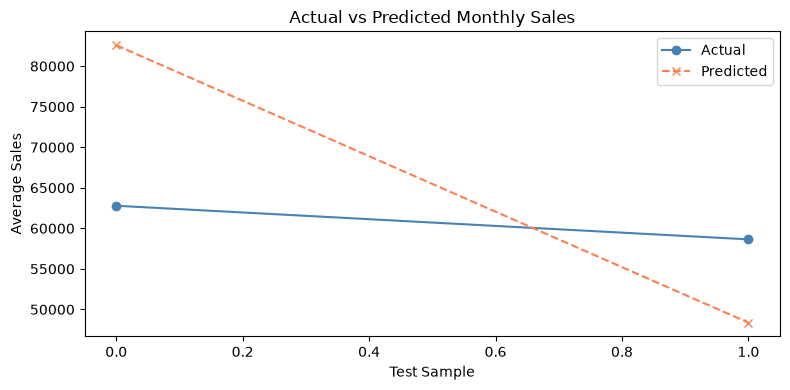

In [247]:
plt.figure(figsize=(8, 4))
plt.plot(y_test.values, label='Actual', marker='o', color='steelblue')
plt.plot(y_pred, label='Predicted', marker='x', linestyle='--', color='coral')
plt.title('Actual vs Predicted Monthly Sales')
plt.xlabel('Test Sample')
plt.ylabel('Average Sales')
plt.legend()
plt.tight_layout()
plt.savefig('regression.png')
plt.show()

### Interpretation

The model has an MAE of 15,031.69, which means its predictions are off by about 15,000 rupees on average from the actual monthly average sales. The R-squared value is -56.848, which is below the acceptable level of 0.5. A negative value means the model predicts worse than simply using the average.

This happened for two reasons. First, only 9 months of data are available, so the test set has just 2 months, which makes the score very unreliable. Second, monthly sales go up and down (for example, July is very high and April and August are low), so a straight line cannot explain the pattern well. More data, such as several years of sales, would give a much better model.

## SECTION 9 — CLASSIFICATION

In [248]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

df_clean['High_Sale'] = (df_clean['TotalAmount'] > df_clean['TotalAmount'].median()).astype(int)
print('High:', df_clean['High_Sale'].sum())
print('Low: ', (df_clean['High_Sale'] == 0).sum())

High: 250
Low:  250


In [249]:
X = df_clean[['Quantity', 'Month_Num']]
y = df_clean['High_Sale']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

              precision    recall  f1-score   support

           0       0.59      0.68      0.63        50
           1       0.62      0.52      0.57        50

    accuracy                           0.60       100
   macro avg       0.60      0.60      0.60       100
weighted avg       0.60      0.60      0.60       100



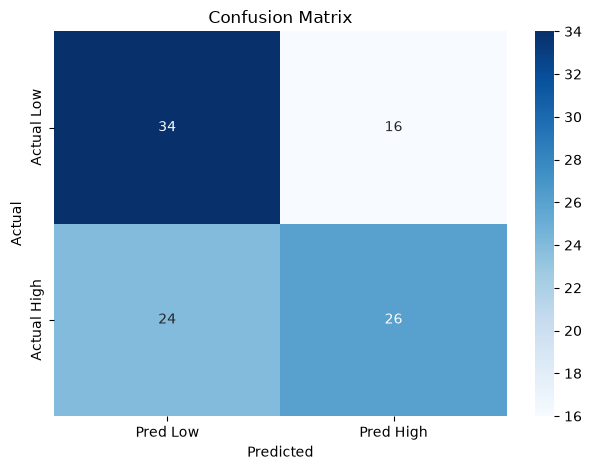

In [250]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Low', 'Pred High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

### Interpretation

The model predicts whether a sale is High or Low using only Quantity and Month. Its F1-score is 0.60, which is below the good level of 0.70, so the model is only moderately accurate (it is right about 60 out of 100 times).

The confusion matrix shows that the model makes the most mistakes on actual High sales: it wrongly predicted 24 of them as Low, while it wrongly predicted 16 Low sales as High. Only 26 of the 50 High sales were identified correctly.

The model is not very strong because it does not use UnitPrice, which is strongly related to the total amount (correlation of 0.83). Quantity alone has only a weak relationship (0.27) with the total amount. Adding UnitPrice would likely improve the results.